## Monter Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installer les bibliothèques

In [ ]:
!pip install -q monai nibabel SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 22.6 MB/s eta 0:00:00


In [ ]:
# installation mlflow
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from pathlib import Path
import mlflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split

from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.data import decollate_batch
from monai.transforms import Compose, Activations, AsDiscrete
from monai.metrics import DiceMetric, MeanIoU


In [ ]:
MLFLOW_TRACKING_URI = "https://elated-autistic-subfloor.ngrok-free.dev"
EXPERIMENT_NAME = "Stroke-Segmentation"

In [ ]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    client = mlflow.MlflowClient()
    client.search_experiments()  # ping simple pour tester la connexion
    print(f"Connexion réussie au serveur MLflow : {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"Impossible de se connecter au serveur MLflow ({MLFLOW_TRACKING_URI})")
    print(f"Erreur : {e}")

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment actif : {EXPERIMENT_NAME}")

Connexion réussie au serveur MLflow : https://elated-autistic-subfloor.ngrok-free.dev
Experiment actif : Stroke-Segmentation


In [ ]:
import monai
print(monai.__version__)

1.6.0


In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/mlops/preprocessed")

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/mlops/models"
os.makedirs(SAVE_DIR, exist_ok=True)

## Lister les patients

In [ ]:
patients = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])

print("Nombre de patients :", len(patients))

Nombre de patients : 240


## Séparer Train / Validation / Test

In [ ]:
train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Train :", len(train_patients))
print("Validation :", len(val_patients))
print("Test :", len(test_patients))

Train : 168
Validation : 36
Test : 36


# Expérience 1 : Segmentation avec un U-Net 3D utilisant les trois modalités

## Création du StrokeDataset

In [ ]:
class StrokeDataset(Dataset):

    def __init__(self, patient_dirs):
        self.patient_dirs = patient_dirs

    def __len__(self):
        return len(self.patient_dirs)

    def __getitem__(self, index):

        patient_dir = self.patient_dirs[index]

        # 1. Charger les trois modalités
        adc = np.load(patient_dir / "adc.npy").astype(np.float32)
        dwi = np.load(patient_dir / "dwi.npy").astype(np.float32)
        flair = np.load(patient_dir / "flair.npy").astype(np.float32)

        # 2. AJOUT ESSENTIEL : Normaliser chaque modalité indépendamment (Z-score)
        if adc.std() > 0: adc = (adc - adc.mean()) / adc.std()
        if dwi.std() > 0: dwi = (dwi - dwi.mean()) / dwi.std()
        if flair.std() > 0: flair = (flair - flair.mean()) / flair.std()

        #  Charger le masque
        mask = np.load(patient_dir / "mask.npy").astype(np.float32)

        # Empiler les modalités
        image = np.stack([adc, dwi, flair], axis=0)

        # Ajouter un canal au masque
        mask = np.expand_dims(mask, axis=0)

        #  Conversion propre vers PyTorch
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float()

        return image, mask


#### Vérifier que tout fonctionne

In [ ]:
train_dataset = StrokeDataset(train_patients)

print("Nombre de patients :", len(train_dataset))
image, mask = train_dataset[0]

print("Image :", image.shape)
print("Masque :", mask.shape)

Nombre de patients : 168
Image : torch.Size([3, 128, 128, 64])
Masque : torch.Size([1, 128, 128, 64])


## Créer les DataLoader

In [ ]:
# Création des datasets
train_dataset = StrokeDataset(train_patients)
val_dataset = StrokeDataset(val_patients)
test_dataset = StrokeDataset(test_patients)

# Création des DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

Train batches      : 168
Validation batches : 36
Test batches       : 36


#### Vérifier que tout fonctionne

In [ ]:
images, masks = next(iter(train_loader))

print("Images :", images.shape)
print("Masks  :", masks.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images : torch.Size([1, 3, 128, 128, 64])
Masks  : torch.Size([1, 1, 128, 128, 64])


## Construction du modèle U-Net 3D

In [ ]:
# Vérifier si un GPU est disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

Device : cpu
False
0


## Définir la Loss et l'Optimizer

In [ ]:
# Post-processing for Validation

from monai.transforms import (
    Compose,
    Activations,
    AsDiscrete
)

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])

post_label = Compose([
    AsDiscrete(threshold=0.5)
])

print("Post-processing transforms defined successfully.")

Post-processing transforms defined successfully.


In [ ]:
from torch.optim import Adam

# Loss Function

loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Segmentation Metrics

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)
# Hyperparameter Experiments

experiments = [

    {
        "name": "Adam_lr5e4_Multimodal",
        "optimizer": Adam,
        "optimizer_name": "Adam",
        "lr": 5e-4
    },

    {
        "name": "Adam_lr1e3_Multimodal",
        "optimizer": Adam,
        "optimizer_name": "Adam",
        "lr": 1e-3
    }
]

print(
    "Loss Function :",
    loss_function
)

print(
    "Experiments :",
    [exp["name"] for exp in experiments]
)

Loss Function : DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)
Experiments : ['Adam_lr5e4_Multimodal', 'Adam_lr1e3_Multimodal']


## Entraînement + Validation


Running experiment: MULTIMODAL-3D_Adam_lr5e4_Multimodal


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr5e4_Multimodal.pth
Epoch [001/50] | Loss: 1.7570 | Dice: 0.0676 | IoU: 0.0407 | LR: 0.000500
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr5e4_Multimodal.pth
Epoch [002/50] | Loss: 1.5182 | Dice: 0.1952 | IoU: 0.1333 | LR: 0.000498
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr5e4_Multimodal.pth
Epoch [003/50] | Loss: 1.3182 | Dice: 0.2327 | IoU: 0.1578 | LR: 0.000496
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr5e4_Multimodal.pth
Epoch [004/50] | Loss: 1.1297 | Dice: 0.3745 | IoU: 0.2676 | LR: 0.000492
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr5e4_Multimodal.pth
Epoch [005/50] | Loss: 0.9580 | Dice: 0.4842 | IoU: 0.3541 | LR: 0.000488
Epoch [006/50] | Loss: 0.8579 | Dice: 0.4623 | IoU: 0.3381 | LR: 0.000482
Model saved: /content/drive/MyDrive/mlops/models/multimo

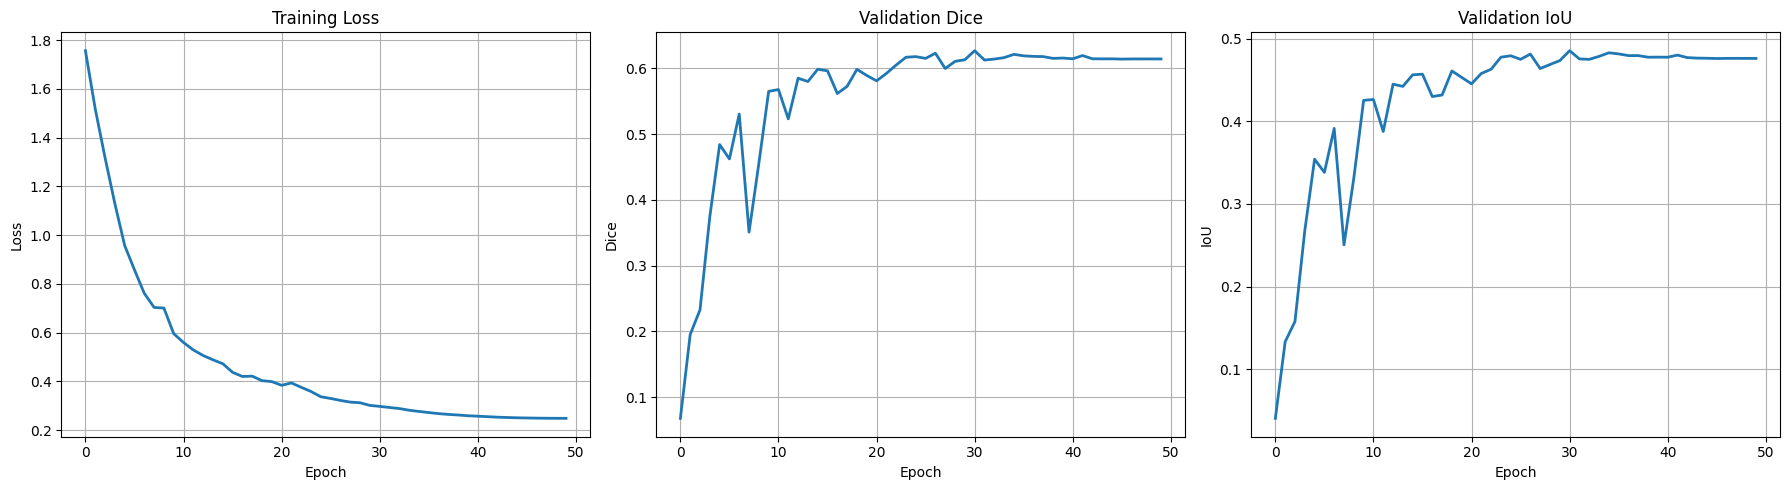

🏃 View run MULTIMODAL-3D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/b4876c4f424b4b06862654fd21fccd16
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

[FIN] Adam_lr5e4_Multimodal -> Best Dice: 0.6269 | Best IoU: 0.4853 | Run ID: b4876c4f424b4b06862654fd21fccd16

Running experiment: MULTIMODAL-3D_Adam_lr1e3_Multimodal
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr1e3_Multimodal.pth
Epoch [001/50] | Loss: 1.7468 | Dice: 0.1066 | IoU: 0.0708 | LR: 0.000999
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr1e3_Multimodal.pth
Epoch [002/50] | Loss: 1.2769 | Dice: 0.2222 | IoU: 0.1495 | LR: 0.000996
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr1e3_Multimodal.pth
Epoch [003/50] | Loss: 1.0455 | Dice: 0.2435 | IoU: 0.1670 | LR: 0.000991
Model saved: /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr

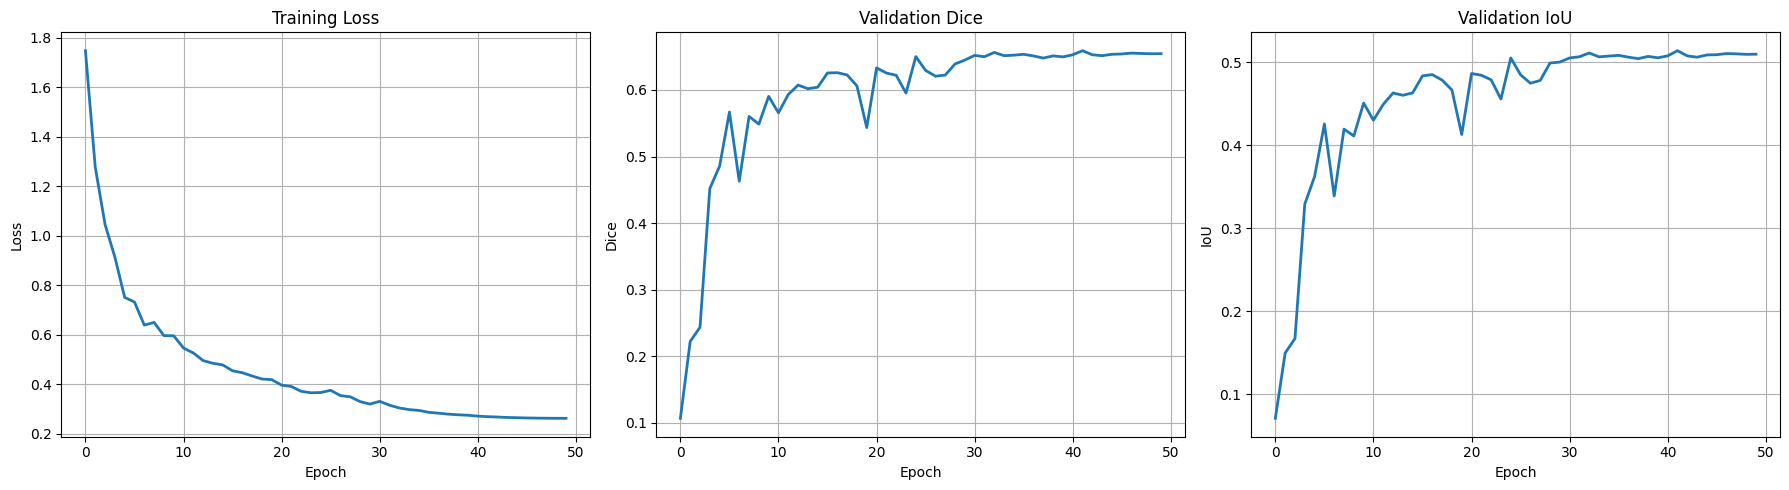

🏃 View run MULTIMODAL-3D_Adam_lr1e3_Multimodal at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/418995088853444dab0f561958cb2d44
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

[FIN] Adam_lr1e3_Multimodal -> Best Dice: 0.6590 | Best IoU: 0.5139 | Run ID: 418995088853444dab0f561958cb2d44

Training completed successfully.


In [ ]:
# MULTIMODAL-3D - MLflow Training
# Modalities: ADC + DWI + FLAIR
num_epochs = 50

results = []

# Save Directory

MULTIMODAL_SAVE_DIR = os.path.join(
    SAVE_DIR,
    "multimodal_3d"
)

os.makedirs(
    MULTIMODAL_SAVE_DIR,
    exist_ok=True
)

# Run Each Experiment

for exp in experiments:

    print("\n" + "=" * 60)

    print(
        f"Running experiment: "
        f"MULTIMODAL-3D_{exp['name']}"
    )

    print("=" * 60)

    # Start MLflow Run

    with mlflow.start_run(
        run_name=f"MULTIMODAL-3D_{exp['name']}"
    ) as run:

        # MLflow Tags

        mlflow.set_tag(
            "experiment_group",
            "MULTIMODAL-3D"
        )

        mlflow.set_tag(
            "modality",
            "ADC+DWI+FLAIR"
        )

        mlflow.set_tag(
            "dimension",
            "3D"
        )

        mlflow.set_tag(
            "dataset",
            "ISLES2022"
        )

        mlflow.set_tag(
            "framework",
            "PyTorch + MONAI"
        )

        # MLflow Parameters

        mlflow.log_param(
            "architecture",
            "3D U-Net"
        )

        mlflow.log_param(
            "model",
            "3D_UNet"
        )

        mlflow.log_param(
            "modality",
            "ADC+DWI+FLAIR"
        )

        mlflow.log_param(
            "dimension",
            "3D"
        )

        mlflow.log_param(
            "optimizer",
            exp["optimizer_name"]
        )

        mlflow.log_param(
            "learning_rate",
            exp["lr"]
        )

        mlflow.log_param(
            "batch_size",
            1
        )

        mlflow.log_param(
            "epochs",
            num_epochs
        )

        mlflow.log_param(
            "num_channels",
            3
        )

        mlflow.log_param(
            "input_modalities",
            "ADC,DWI,FLAIR"
        )

        mlflow.log_param(
            "channels",
            str((16, 32, 64, 128, 256))
        )

        mlflow.log_param(
            "strides",
            str((2, 2, 2, 2))
        )

        mlflow.log_param(
            "num_res_units",
            2
        )

        mlflow.log_param(
            "scheduler",
            "CosineAnnealingLR"
        )

        mlflow.log_param(
            "loss_function",
            "DiceCELoss"
        )

        mlflow.log_param(
            "lambda_dice",
            1.5
        )

        mlflow.log_param(
            "lambda_ce",
            0.5
        )

        # Create 3D U-Net

        model = UNet(
            spatial_dims=3,
            in_channels=3,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
        ).to(device)

        # Optimizer

        optimizer = exp["optimizer"](
            model.parameters(),
            lr=exp["lr"]
        )

        # Learning Rate Scheduler

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )

        # Best Model Tracking

        best_dice = 0.0

        best_iou = 0.0

        best_epoch = 0

        train_losses = []

        val_dices = []

        val_ious = []

        # Model Save Path

        model_path = os.path.join(
            MULTIMODAL_SAVE_DIR,
            f"best_model_{exp['name']}.pth"
        )

        # Training Loop

        for epoch in range(num_epochs):

            # Training

            model.train()

            epoch_loss = 0.0

            for images, masks in train_loader:

                images = images.to(device)

                masks = masks.to(device)

                optimizer.zero_grad()

                outputs = model(images)

                loss = loss_function(
                    outputs,
                    masks
                )

                loss.backward()

                optimizer.step()

                epoch_loss += loss.item()

            epoch_loss /= len(train_loader)

            train_losses.append(
                epoch_loss
            )

            # Validation

            model.eval()

            dice_metric.reset()

            iou_metric.reset()

            with torch.no_grad():

                for val_images, val_masks in val_loader:

                    val_images = val_images.to(device)

                    val_masks = val_masks.to(device)

                    val_outputs = model(
                        val_images
                    )

                    # Convert predictions to binary masks

                    val_outputs = [
                        post_pred(i)
                        for i in decollate_batch(
                            val_outputs
                        )
                    ]

                    # Convert ground truth to binary masks

                    val_masks = [
                        post_label(i)
                        for i in decollate_batch(
                            val_masks
                        )
                    ]

                    # Update Dice metric

                    dice_metric(
                        y_pred=val_outputs,
                        y=val_masks
                    )

                    # Update IoU metric
                    iou_metric(
                        y_pred=val_outputs,
                        y=val_masks
                    )

            # Aggregate Validation Metrics
            dice = dice_metric.aggregate().item()

            iou = iou_metric.aggregate().item()

            dice_metric.reset()

            iou_metric.reset()

            val_dices.append(
                dice
            )

            val_ious.append(
                iou
            )

            # Scheduler

            scheduler.step()

            # MLflow - Log Epoch Metrics

            mlflow.log_metric(
                "train_loss",
                epoch_loss,
                step=epoch + 1
            )

            mlflow.log_metric(
                "val_dice",
                dice,
                step=epoch + 1
            )

            mlflow.log_metric(
                "val_iou",
                iou,
                step=epoch + 1
            )

            # Save Best Model

            if dice > best_dice:

                best_dice = dice

                best_iou = iou

                best_epoch = epoch + 1

                torch.save(
                    model.state_dict(),
                    model_path
                )

                print(
                    f"Model saved: {model_path}"
                )

            # Current Learning Rate

            current_lr = (
                optimizer.param_groups[0]["lr"]
            )

            # Display Epoch Results

            print(
                f"Epoch [{epoch + 1:03d}/{num_epochs}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f} "
                f"| LR: {current_lr:.6f}"
            )

        # MLflow - Log Best Metrics

        mlflow.log_metric(
            "best_dice",
            best_dice
        )

        mlflow.log_metric(
            "best_iou",
            best_iou
        )

        mlflow.log_metric(
            "best_epoch",
            best_epoch
        )

        # MLflow - Log Best Model

        mlflow.log_artifact(
            model_path,
            artifact_path="model"
        )

        # Create Training Curves

        curve_path = os.path.join(
            MULTIMODAL_SAVE_DIR,
            f"training_curves_{exp['name']}.png"
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(18, 5)
        )

        # Training Loss

        axes[0].plot(
            train_losses,
            linewidth=2
        )

        axes[0].set_title(
            "Training Loss"
        )

        axes[0].set_xlabel(
            "Epoch"
        )

        axes[0].set_ylabel(
            "Loss"
        )

        axes[0].grid(
            True
        )

        # Validation Dice

        axes[1].plot(
            val_dices,
            linewidth=2
        )

        axes[1].set_title(
            "Validation Dice"
        )

        axes[1].set_xlabel(
            "Epoch"
        )

        axes[1].set_ylabel(
            "Dice"
        )

        axes[1].grid(
            True
        )

        # Validation IoU

        axes[2].plot(
            val_ious,
            linewidth=2
        )

        axes[2].set_title(
            "Validation IoU"
        )

        axes[2].set_xlabel(
            "Epoch"
        )

        axes[2].set_ylabel(
            "IoU"
        )

        axes[2].grid(
            True
        )

        plt.tight_layout()

        # Save Training Curves

        plt.savefig(
            curve_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        plt.close(
            fig
        )

        # MLflow - Log Training Curves

        mlflow.log_artifact(
            curve_path,
            artifact_path="plots"
        )

        # Get MLflow Run ID

        run_id = run.info.run_id

    # Store Experiment Results

    results.append({

        "Experiment":
            exp["name"],

        "Run Name":
            f"MULTIMODAL-3D_{exp['name']}",

        "Run ID":
            run_id,

        "Learning Rate":
            exp["lr"],

        "Best Dice":
            best_dice,

        "Best IoU":
            best_iou,

        "Best Epoch":
            best_epoch,

        "Train Loss":
            train_losses,

        "Validation Dice":
            val_dices,

        "Validation IoU":
            val_ious,

        "Model Path":
            model_path
    })

    # Display Final Experiment Result

    print(
        f"\n[FIN] {exp['name']} "
        f"-> Best Dice: {best_dice:.4f} "
        f"| Best IoU: {best_iou:.4f} "
        f"| Run ID: {run_id}"
    )

# Training Completed

print(
    "\nTraining completed successfully."
)

## Afficher les performances finales

In [ ]:
# Comparison of MULTIMODAL-3D Experiments

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by="Best Dice",
    ascending=False
).reset_index(drop=True)

comparison_columns = [
    "Run Name",
    "Run ID",
    "Learning Rate",
    "Best Dice",
    "Best IoU",
    "Best Epoch",
    "Model Path"
]

print("=" * 80)
print("Comparison of MULTIMODAL-3D Experiments")
print("=" * 80)

display(
    df_results[comparison_columns]
)

Comparison of MULTIMODAL-3D Experiments


,Run Name,Run ID,Learning Rate,Best Dice,Best IoU,Best Epoch,Model Path
0,MULTIMODAL-3D_Adam_lr1e3_Multimodal,418995088853444dab0f561958cb2d44,0.0010,0.659001,0.513894,42,/content/drive/MyDrive/mlops/models/multimodal...
1,MULTIMODAL-3D_Adam_lr5e4_Multimodal,b4876c4f424b4b06862654fd21fccd16,0.0005,0.626886,0.485299,31,/content/drive/MyDrive/mlops/models/multimodal...


## Tracer la courbe de Loss et du Dice

In [ ]:
print(type(results))
print(len(results))

print(results[0].keys())

<class 'list'>
2
dict_keys(['Experiment', 'Run Name', 'Run ID', 'Learning Rate', 'Best Dice', 'Best IoU', 'Best Epoch', 'Train Loss', 'Validation Dice', 'Validation IoU', 'Model Path'])


In [ ]:
print(type(results[0]["Train Loss"]))
print(results[0]["Train Loss"])

<class 'list'>
[1.7569972283783413, 1.5182431531803948, 1.3181984264935767, 1.1297323097075735, 0.9580278281299841, 0.8579200562089682, 0.7617567390913055, 0.703892688976512, 0.7012873778474473, 0.5960450615467769, 0.5600926695568931, 0.5294697529059791, 0.5065355363878465, 0.4889830147758836, 0.47293092044336454, 0.43778850320017054, 0.4205897015386394, 0.4219682560790153, 0.40338707759621595, 0.39943600601206225, 0.38441932751309305, 0.3940261422789523, 0.3761516563771736, 0.35901255861279513, 0.33734370794679436, 0.33036722149699926, 0.32224474377220585, 0.31542424564915045, 0.3127274409912172, 0.30184309588124353, 0.29792602515468997, 0.29323616184826407, 0.2890597674108687, 0.2820505568580258, 0.27716418923366637, 0.2725573881041436, 0.2682264658312003, 0.26496288189220996, 0.2624794849238935, 0.2594673324465042, 0.25764558242545244, 0.2556086139576066, 0.2536300789298756, 0.25226375088095665, 0.251105943073829, 0.25030875041903483, 0.24969252598072803, 0.2492292859103708, 0.24896

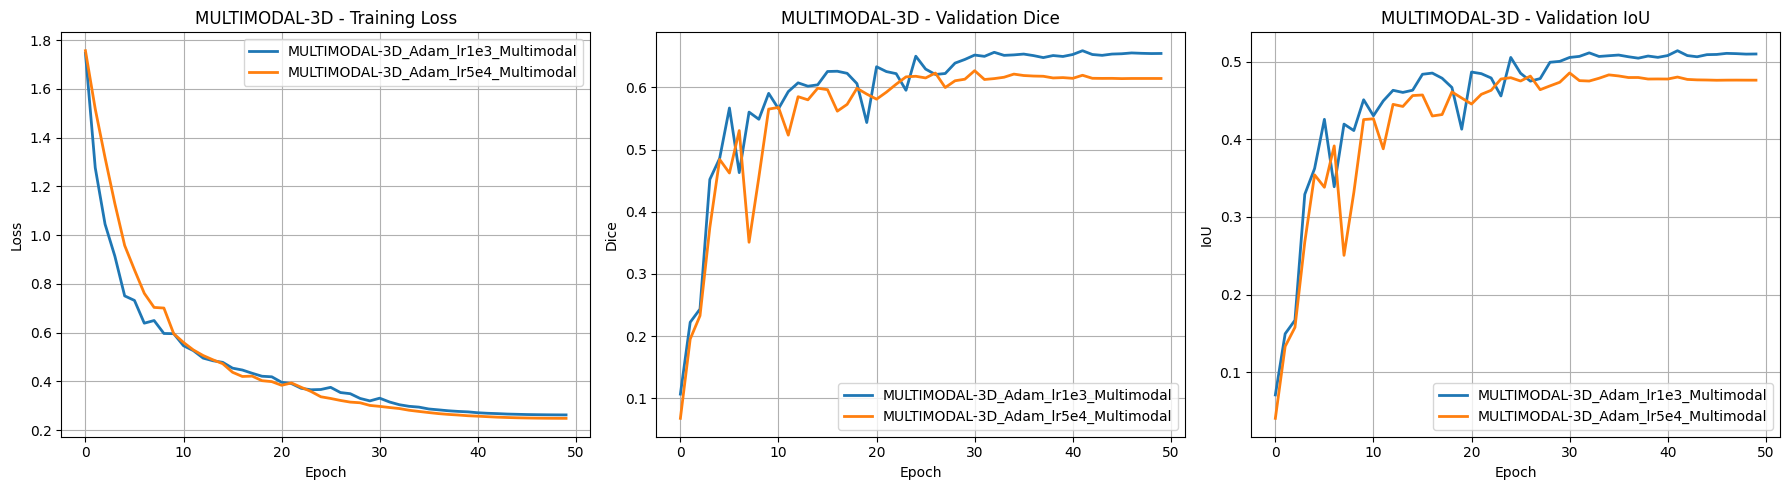

In [ ]:
plt.figure(figsize=(18, 5))

# Training Loss
plt.subplot(1, 3, 1)

for _, row in df_results.iterrows():

    plt.plot(
        row["Train Loss"],
        linewidth=2,
        label=row["Run Name"]
    )

plt.title(
    "MULTIMODAL-3D - Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Validation Dice
plt.subplot(1, 3, 2)

for _, row in df_results.iterrows():

    plt.plot(
        row["Validation Dice"],
        linewidth=2,
        label=row["Run Name"]
    )

plt.title(
    "MULTIMODAL-3D - Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid(True)
plt.legend()

# Validation IoU

plt.subplot(1, 3, 3)

for _, row in df_results.iterrows():

    plt.plot(
        row["Validation IoU"],
        linewidth=2,
        label=row["Run Name"]
    )

plt.title(
    "MULTIMODAL-3D - Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save Comparison

comparison_curve_path = os.path.join(
    MULTIMODAL_SAVE_DIR,
    "comparison_training_curves.png"
)

plt.savefig(
    comparison_curve_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Visualiser la prédiction

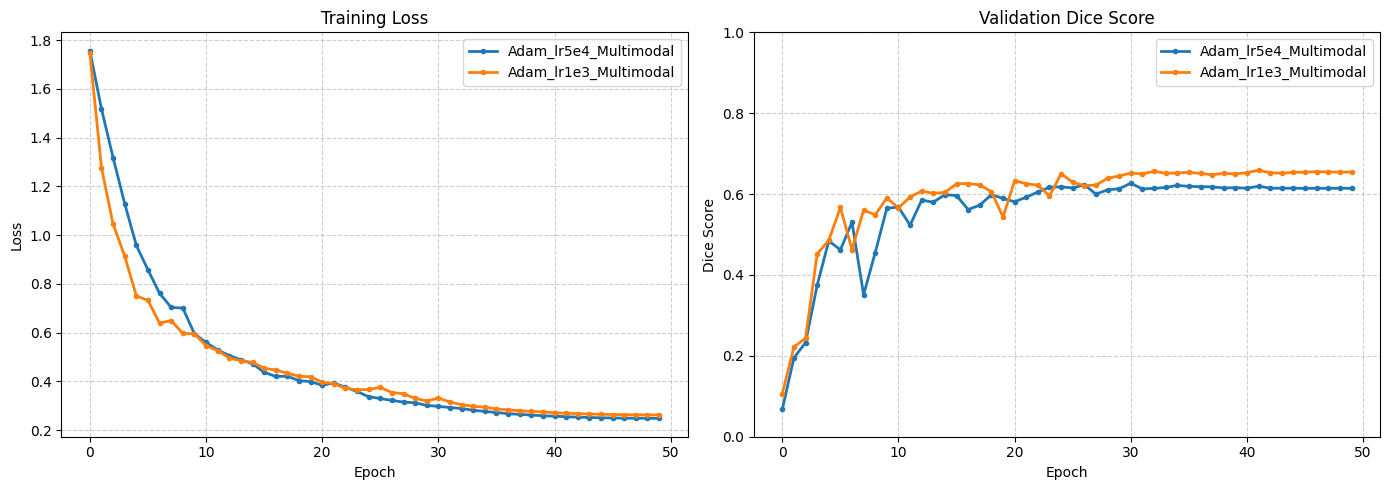

In [ ]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

plt.figure(figsize=(14, 5))

# Training Loss
plt.subplot(1, 2, 1)

for _, row in results_df.iterrows():
    plt.plot(
        row["Train Loss"],
        linewidth=2,
        marker="o",
        markersize=3,
        label=row["Experiment"]
    )

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Validation Dice Score
plt.subplot(1, 2, 2)

for _, row in results_df.iterrows():
    plt.plot(
        row["Validation Dice"],
        linewidth=2,
        marker="o",
        markersize=3,
        label=row["Experiment"]
    )

plt.title("Validation Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

evaluation de model

In [ ]:
best_result = max(
    results,
    key=lambda x: x["Best Dice"]
)

print("=" * 60)

print(
    "Best Run Name :",
    best_result["Run Name"]
)

print(
    "Best Dice     :",
    f"{best_result['Best Dice']:.4f}"
)

print(
    "Best IoU      :",
    f"{best_result['Best IoU']:.4f}"
)

print(
    "Best Epoch    :",
    best_result["Best Epoch"]
)

print(
    "Run ID        :",
    best_result["Run ID"]
)

print(
    "Model Path    :",
    best_result["Model Path"]
)

print("=" * 60)

# Recreate Best Model

model = UNet(
    spatial_dims=3,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# Load Best Weights
model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=device
    )
)

model.eval()

print(
    "Best MULTIMODAL-3D model loaded successfully."
)

Best Run Name : MULTIMODAL-3D_Adam_lr1e3_Multimodal
Best Dice     : 0.6590
Best IoU      : 0.5139
Best Epoch    : 42
Run ID        : 418995088853444dab0f561958cb2d44
Model Path    : /content/drive/MyDrive/mlops/models/multimodal_3d/best_model_Adam_lr1e3_Multimodal.pth
Best MULTIMODAL-3D model loaded successfully.
